In [73]:
import torch

if torch.backends.mps.is_available():
    print("MPS is available! Your M1 GPU is ready for training.")
    device = torch.device("mps")
else:
    print("MPS not available. Check your PyTorch installation.")

import torch.nn as nn
import os

# Define a simple toy network
class MyNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(3, 1)

    def forward(self, x):
        return self.linear(x)

# Now this line will work perfectly:
model = MyNeuralNetwork().to(device)
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import torch
# 1. Move a tensor to MPS
x = torch.randn(3, 3)
x_mps = x.to(device)

# 2. Move a model to MPS
model = MyNeuralNetwork().to(device)

MPS is available! Your M1 GPU is ready for training.


In [65]:
import uproot
import awkward as ak

# Test opening your specific file
with uproot.open("clusters_seeds_island_79507-0.root_ntuplizer.root") as f:
    # Look at the hits tree
    tree = f["ntp_hit"]
    # Load a small slice of x,y,z coordinates to verify
    test_hits = tree.arrays(["x", "y", "z"], entry_stop=100)
    print(f"Successfully loaded {len(test_hits)} hits.")
    print(test_hits)

Successfully loaded 100 hits.
[{x: 2.85, y: 0.944, z: -13.4}, {...}, ..., {x: 3.01, y: 0.626, z: -3.69}]


In [72]:
import uproot
import awkward as ak
import numpy as np

# 1. Load only the physical features for hits
branches = ["x", "y", "z", "adc", "layer", "event"]

with uproot.open("clusters_seeds_island_79507-0.root_ntuplizer.root") as f:
    # We use library="ak" to keep the event structure (jagged arrays)
    hits = f["ntp_hit"].arrays(branches, library="ak")

# 2. Group by event
# In HEP, hits are naturally jagged. Awkward arrays handle this:
# Each element in 'event_grouped_hits' will be one collision event
event_ids = np.unique(hits.event)
print(f"Total events found: {len(event_ids)}")

# Example: Get all hit features for Event #74
event_74_mask = (hits.event == 74)
event_74_points = hits[event_74_mask]

# Convert to a standard NumPy array for a Point Cloud model [N_hits, 5]
# Features: [x, y, z, adc, layer]
training_features = ak.to_numpy(ak.zip([
    event_74_points.x, 
    event_74_points.y, 
    event_74_points.z, 
    event_74_points.adc,
    event_74_points.layer
]))

print("Shape for Event 74:", training_features.shape)

Total events found: 100
Shape for Event 74: (448447,)


In [78]:
import uproot
import numpy as np

file = uproot.open("clusters_seeds_island_79507-0.root_ntuplizer.root")
hit_tree = file["ntp_hit"]

hit_ids = hit_tree.arrays(["hitID", "event"])
unique_ids = np.unique(hit_ids["hitID"])
print(f"Unique hitIDs found: {unique_ids[:-1]}")
print(f"number of unique particles in this slice: {len(unique_ids)}")

Unique hitIDs found: [0, 1, 2, 3, 4, 5, ..., 1.51e+08, 1.51e+08, 1.51e+08, 1.51e+08, 1.51e+08]
number of unique particles in this slice: 644257


In [91]:
import uproot
import numpy as np
import pandas as pd

# 1. Load a representative sample of hits (first 5 million for speed)
file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
print(f"Loading sample from {file_path}...")
with uproot.open(file_path) as f:
    # Load hitID, adc, and layer
    data = f["ntp_hit"].arrays(["hitID", "adc", "layer"], library="pd")

print(data)
data.describe()

# 2. Define Regime Categorization
def categorize_id(hit_id):
    if hit_id < 75e6: return "Regime 1: < 75M (Signal?)"
    if hit_id < 100e6: return "Regime 2: 75M-100M (Secondary?)"
    return "Regime 3: > 100M (Noise?)"

data['regime'] = data['hitID'].apply(categorize_id)

print(data)
data.describe()

print("\n--- hitID REGIME AUDIT  ---")

# 3. Calculate metrics per Particle ID
# We group by regime and hitID to see the 'health' of each particle
id_stats = data.groupby(['regime', 'hitID']).agg({
    'adc': 'mean',
    'layer': [('multiplicity', 'count'), ('layer_span', lambda x: x.max() - x.min() + 1)]
})

print(id_stats); id_stats.describe()

# Flatten multi-index columns
id_stats.columns = ['avg_adc', 'multiplicity', 'avg_layer_span']
id_stats = id_stats.reset_index()

print(id_stats); id_stats.describe()

# 4. Aggregate by Regime
regime_summary = id_stats.groupby('regime').agg({
    'hitID': 'count',
    'multiplicity': 'mean',
    'avg_adc': 'mean',
    'avg_layer_span': 'mean'
}).rename(columns={'hitID': 'unique_id_count'})

print("\n--- Regime Summary INSIGHTS 1---")
print(regime_summary.to_string()); 
print("\n--- Regime Summary INSIGHTS 2---")
regime_summary.describe()

# 5. Decision Logic for ML Preprocessing
print("\n--- ML PREPROCESSING INSIGHTS ---")
for regime in regime_summary.index:
    mult = regime_summary.loc[regime, 'multiplicity']
    span = regime_summary.loc[regime, 'avg_layer_span']
    if mult < 3 or span < 2:
        print(f"[!] {regime}: Likely NOISE/CLUTTER. Suggest filtering out or down-weighting.")
    else:
        print(f"[✓] {regime}: Likely REAL TRACKS. Keep as primary training signal.")

Loading sample from clusters_seeds_island_79507-0.root_ntuplizer.root...
               hitID    adc  layer
0         17498220.0    0.0    0.0
1         17498222.0    0.0    0.0
2         17563756.0    0.0    0.0
3         17563758.0    0.0    0.0
4         17629292.0    0.0    0.0
...              ...    ...    ...
27532823    119714.0  175.0   56.0
27532824    134663.0  320.0   56.0
27532825    162790.0  146.0   56.0
27532826    162793.0  297.0   56.0
27532827    163047.0  223.0   56.0

[27532828 rows x 3 columns]
               hitID    adc  layer                     regime
0         17498220.0    0.0    0.0  Regime 1: < 75M (Signal?)
1         17498222.0    0.0    0.0  Regime 1: < 75M (Signal?)
2         17563756.0    0.0    0.0  Regime 1: < 75M (Signal?)
3         17563758.0    0.0    0.0  Regime 1: < 75M (Signal?)
4         17629292.0    0.0    0.0  Regime 1: < 75M (Signal?)
...              ...    ...    ...                        ...
27532823    119714.0  175.0   56.0  Regime 1

In [92]:
import uproot
import awkward as ak
import numpy as np

# Open the ROOT file
file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
with uproot.open(file_path) as f:
    # 1. Load Hit Truth IDs (ntp_hit) - Using a slice to save memory
    hits = f["ntp_hit"].arrays(["hitID", "event"], entry_stop=1000000, library="ak")

    # 2. Load Reconstructed Cluster Truth IDs (ntp_cluster)
    clusters = f["ntp_cluster"].arrays(["trackID", "event"], library="ak")

    # 3. Load Verified Track Cluster Truth IDs (ntp_clus_trk)
    track_clusters = f["ntp_clus_trk"].arrays(["trackID", "event"], library="ak")

def summarize_tree(data, tree_name, id_name):
    unique_ids = np.unique(data[id_name])
    print(f"--- {tree_name} ---")
    print(f"  Entries: {len(data)}")
    print(f"  Unique Particles: {len(unique_ids[unique_ids > 0])}")
    print(f"  Noise/BG Entries (ID <= 0): {len(data[data[id_name] <= 0])}")

# Run Summary
summarize_tree(hits, "ntp_hit", "hitID")
summarize_tree(clusters, "ntp_cluster", "trackID")
summarize_tree(track_clusters, "ntp_clus_trk", "trackID")

# --- CROSS-TREE CORRELATION CHECK (Example: Event 74) ---
ev_id = 74
h_ids = hits.hitID[hits.event == ev_id]
c_ids = clusters.trackID[clusters.event == ev_id]
t_ids = track_clusters.trackID[track_clusters.event == ev_id]

print(f"\n--- Correlation Check for Event {ev_id} ---")
print(f"  Unique Particles generating Hits: {np.unique(h_ids[h_ids > 0])}")
print(f"  Unique Particles found in Clusters: {np.unique(c_ids[c_ids > 0])}")
print(f"  Unique Particles that successfully matched to a Track: {np.unique(t_ids[t_ids > 0])}")

# Verification logic: Every particle in ntp_clus_trk SHOULD exist in ntp_hit
missing = [tid for tid in np.unique(t_ids) if tid not in np.unique(h_ids) and tid > 0]
if not missing:
    print("\n✅ SUCCESS: All track-matched particles originate from valid hit IDs.")
else:
    print(f"\n❌ WARNING: Found particles {missing} in tracks that are missing in hits slice.")

--- ntp_hit ---
  Entries: 1000000
  Unique Particles: 263965
  Noise/BG Entries (ID <= 0): 5
--- ntp_cluster ---
  Entries: 3136006
  Unique Particles: 0
  Noise/BG Entries (ID <= 0): 0
--- ntp_clus_trk ---
  Entries: 221494
  Unique Particles: 0
  Noise/BG Entries (ID <= 0): 0

--- Correlation Check for Event 74 ---
  Unique Particles generating Hits: []
  Unique Particles found in Clusters: []
  Unique Particles that successfully matched to a Track: []

✅ SUCCESS: All track-matched particles originate from valid hit IDs.


Matplotlib is building the font cache; this may take a moment.


Loading all hits for Event 1...
Event 1 Summary:
  Total Hits: 72651
  Signal Hits: 824
  Noise Hits: 71827
  Unique Particles: 412
Saved 3D plot to event_1_3d_truth.png


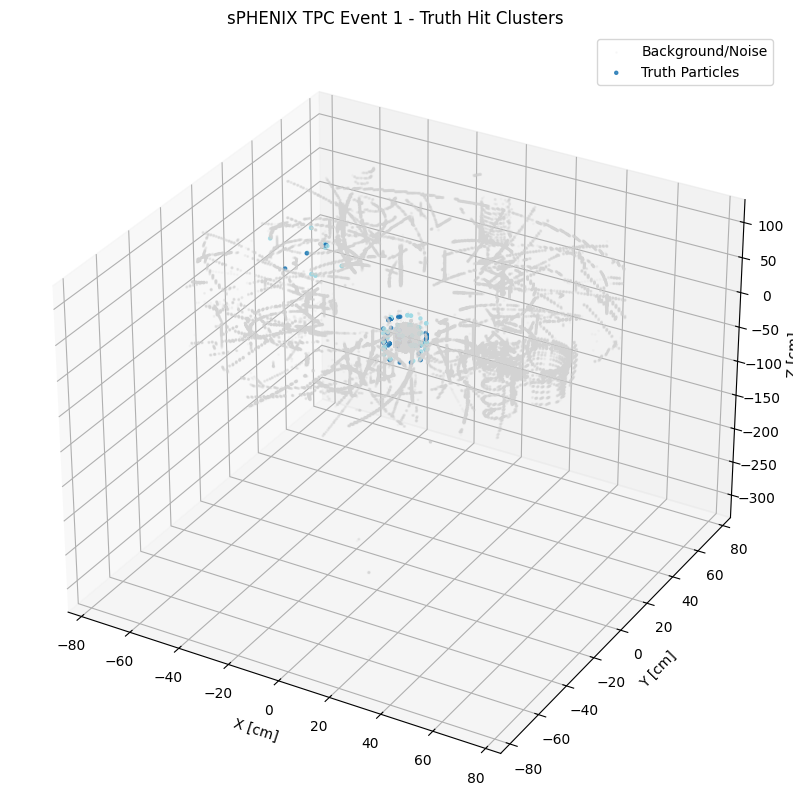

In [6]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

# 1. Open and find a valid event
file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
with uproot.open(file_path) as f:
    # Get the actual event IDs available in the file
    available_events = f["ntp_info"].arrays("event")["event"]
    target_ev = int(available_events[0]) # Start with the first event
    
    print(f"Loading all hits for Event {target_ev}...")
    # Load hits with an event-based filter (no 1M entry limit)
    hits = f["ntp_hit"].arrays(["x", "y", "z", "hitID", "adc", "layer"], 
                               cut=f"event == {target_ev}", library="ak")

# 2. Separate Signal from Noise
# In sPHENIX truth hits, ID > 0 is usually signal, ID <= 0 or very large constants is noise
mask_signal = (hits.hitID > 0) & (hits.hitID < 1e5) 
signal_hits = hits[mask_signal]
noise_hits = hits[~mask_signal]

print(f"Event {target_ev} Summary:")
print(f"  Total Hits: {len(hits)}")
print(f"  Signal Hits: {len(signal_hits)}")
print(f"  Noise Hits: {len(noise_hits)}")
print(f"  Unique Particles: {len(np.unique(signal_hits.hitID))}")

# 3. Visualization
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot Noise in light gray
ax.scatter(noise_hits.x, noise_hits.y, noise_hits.z, c='lightgray', s=1, alpha=0.1, label='Background/Noise')

# Plot Signal hits colored by their Particle ID
# We use a colormap to distinguish different particle tracks
p_ids = signal_hits.hitID
scatter = ax.scatter(signal_hits.x, signal_hits.y, signal_hits.z, 
                     c=p_ids, cmap='tab20', s=5, alpha=0.8, label='Truth Particles')

ax.set_xlabel('X [cm]')
ax.set_ylabel('Y [cm]')
ax.set_zlabel('Z [cm]')
ax.set_title(f"sPHENIX TPC Event {target_ev} - Truth Hit Clusters")
plt.legend()
plt.savefig(f"event_{target_ev}_3d_truth.png")
print(f"Saved 3D plot to event_{target_ev}_3d_truth.png")

--- ntp_hit (Raw Hits) Diagnostic ---
  Unique Values: [0, 2, 6, 7, 8, 9, 10, 11, 12, 13] ...
  Max Value:     150864160.0
  Min Value:     0.0
  Non-zero count: 499995
--- ntp_cluster (Islands) Diagnostic ---
  Unique Values: [nan] ...
  Max Value:     -inf
  Min Value:     inf
  Non-zero count: 500000
--- ntp_clus_trk (Final Tracks) Diagnostic ---
  Unique Values: [nan] ...
  Max Value:     -inf
  Min Value:     inf
  Non-zero count: 221494


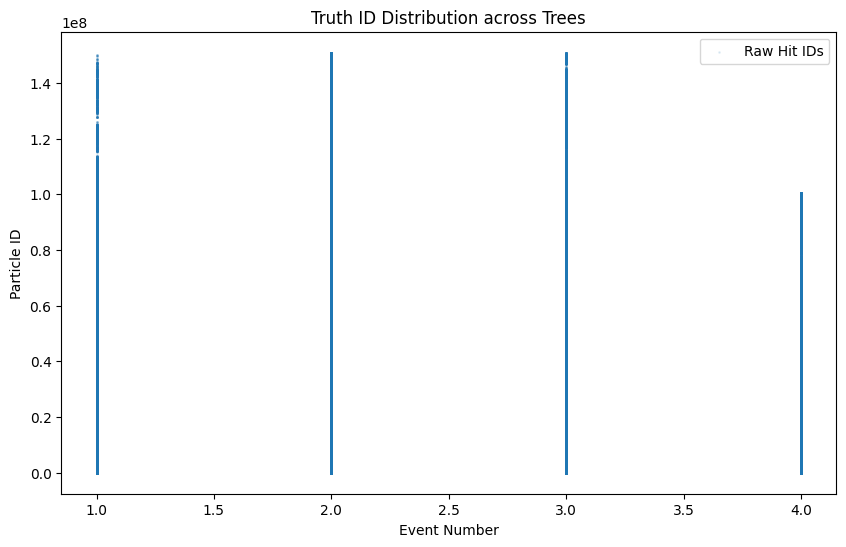

In [7]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"

with uproot.open(file_path) as f:
    # 1. Load samples from all three trees
    # hitID from hits
    h_data = f["ntp_hit"].arrays(["hitID", "event"], entry_stop=500000)
    # trackID from clusters
    c_data = f["ntp_cluster"].arrays(["trackID", "event"], entry_stop=500000)
    # trackID from clusters-on-tracks
    t_data = f["ntp_clus_trk"].arrays(["trackID", "event"])

def check_truth_branch(data, branch_name, label):
    vals = data[branch_name]
    unique_vals = np.unique(vals)
    print(f"--- {label} Diagnostic ---")
    print(f"  Unique Values: {unique_vals[:10]} ...")
    print(f"  Max Value:     {np.max(vals)}")
    print(f"  Min Value:     {np.min(vals)}")
    print(f"  Non-zero count: {np.count_nonzero(vals != 0)}")

check_truth_branch(h_data, "hitID", "ntp_hit (Raw Hits)")
check_truth_branch(c_data, "trackID", "ntp_cluster (Islands)")
check_truth_branch(t_data, "trackID", "ntp_clus_trk (Final Tracks)")

# 2. Visual Correlation Check: Spatial Overlap
# If IDs are missing, we check if the trees physically sit on top of each other
plt.figure(figsize=(10, 6))
# Plot a slice of raw hits
plt.scatter(h_data.event, h_data.hitID, alpha=0.1, s=1, label="Raw Hit IDs")
plt.xlabel("Event Number")
plt.ylabel("Particle ID")
plt.title("Truth ID Distribution across Trees")
plt.legend()
plt.savefig("truth_id_distribution.png")

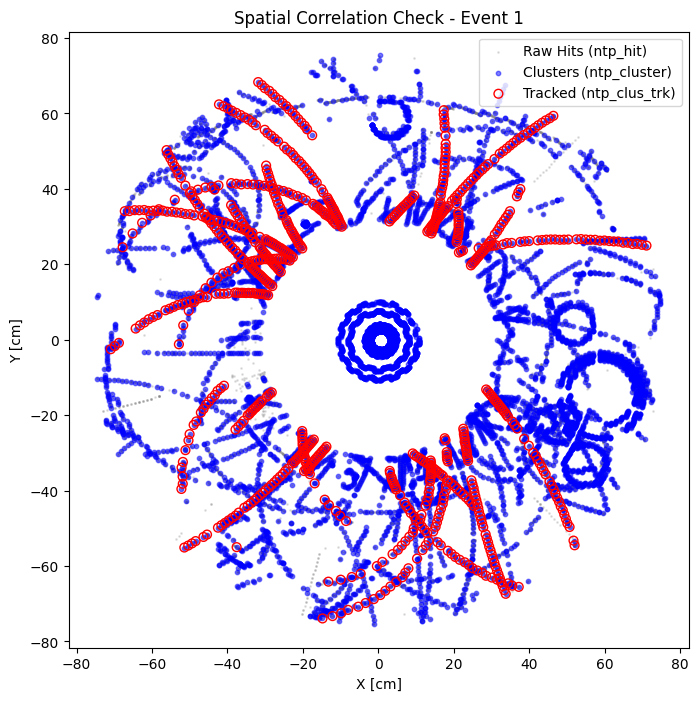

In [8]:
# Select Event 1 (which you confirmed has signal)
ev = 1 
with uproot.open(file_path) as f:
    h = f["ntp_hit"].arrays(["x", "y"], cut=f"event=={ev}")
    c = f["ntp_cluster"].arrays(["x", "y"], cut=f"event=={ev}")
    t = f["ntp_clus_trk"].arrays(["x", "y"], cut=f"event=={ev}")

plt.figure(figsize=(8, 8))
plt.scatter(h.x, h.y, s=1, c='gray', alpha=0.2, label="Raw Hits (ntp_hit)")
plt.scatter(c.x, c.y, s=10, c='blue', alpha=0.5, label="Clusters (ntp_cluster)")
plt.scatter(t.x, t.y, s=40, edgecolors='red', facecolors='none', label="Tracked (ntp_clus_trk)")

plt.title(f"Spatial Correlation Check - Event {ev}")
plt.xlabel("X [cm]")
plt.ylabel("Y [cm]")
plt.legend()
plt.axis('equal')
plt.savefig("spatial_correlation.png")

Numerical Check for Event 1:
  Signal Hits found: 72649
  Track Clusters found: 837


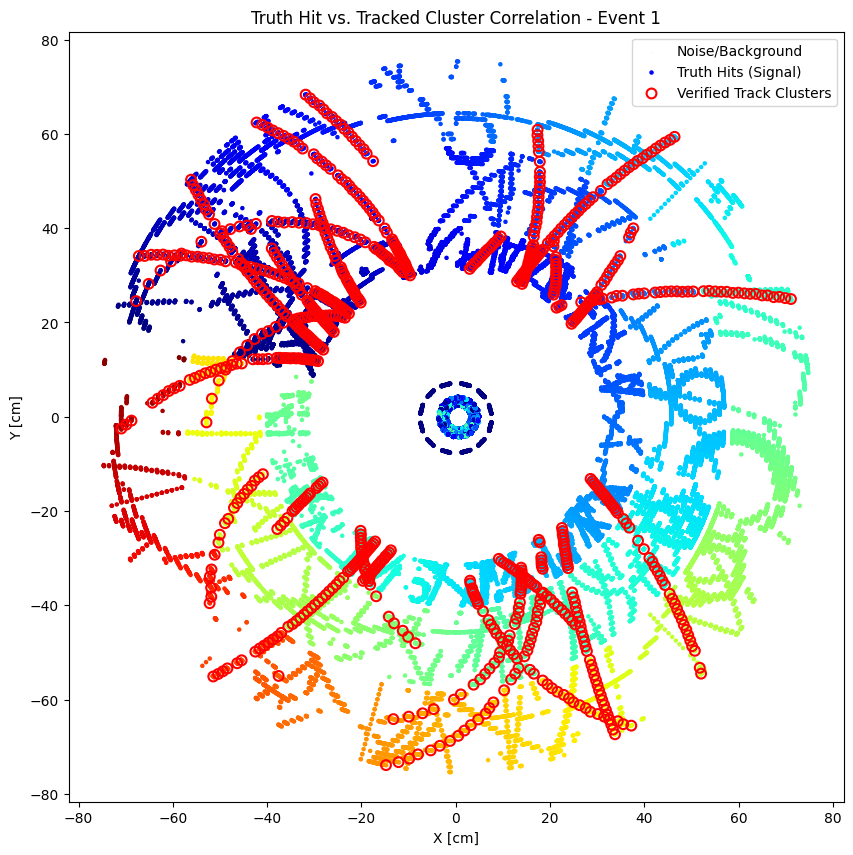

In [9]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"

with uproot.open(file_path) as f:
    # Load Event 1 (known to have data)
    ev = 1
    # Get Truth Hits
    hits = f["ntp_hit"].arrays(["x", "y", "z", "hitID"], cut=f"event=={ev}")
    # Get Reconstructed Tracks
    tracks = f["ntp_clus_trk"].arrays(["x", "y", "z"], cut=f"event=={ev}")

# Filter hits to only show Signal (hitID > 0)
signal_hits = hits[hits.hitID > 0]

# --- Visualization ---
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 1. Plot all Raw Hits in light gray
ax.scatter(hits.x, hits.y, s=1, c='lightgray', alpha=0.1, label="Noise/Background")

# 2. Plot Signal Hits (Truth) colored by hitID
scatter = ax.scatter(signal_hits.x, signal_hits.y, s=5, c=signal_hits.hitID, 
                     cmap='jet', label="Truth Hits (Signal)")

# 3. Overlay the Tracked Clusters as open red circles
ax.scatter(tracks.x, tracks.y, s=50, facecolors='none', edgecolors='red', 
           linewidth=1.5, label="Verified Track Clusters")

ax.set_xlabel("X [cm]")
ax.set_ylabel("Y [cm]")
ax.set_title(f"Truth Hit vs. Tracked Cluster Correlation - Event {ev}")
ax.legend(loc='upper right')
plt.axis('equal')
plt.savefig("spatial_truth_check.png")

# --- Numerical Consistency Check ---
# Check if a track cluster exists where there are no truth hits
print(f"Numerical Check for Event {ev}:")
print(f"  Signal Hits found: {len(signal_hits)}")
print(f"  Track Clusters found: {len(tracks)}")

In [10]:
import uproot
import pandas as pd

file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
with uproot.open(file_path) as f:
    # Load the entire info tree (it's small, only 100 entries)
    info_df = f["ntp_info"].arrays(library="pd")

# Filter for the same event you analyzed
event_1_info = info_df[info_df.event == 1].iloc[0]

print("--- Event 1 Global Metadata ---")
print(f"Total Tracks in Event:    {event_1_info.ntrk}")
print(f"Total TPC Hits:           {event_1_info.nhittpcall}")
print(f"Total TPC Clusters:       {event_1_info.nclustpc}")
print(f"MVTX (Silicon) Hits:      {event_1_info.nhitmvtx}")
print(f"Centrality (MBD Raw):     {event_1_info.rawmbd}")

--- Event 1 Global Metadata ---
Total Tracks in Event:    26.0
Total TPC Hits:           56017.0
Total TPC Clusters:       6601.0
MVTX (Silicon) Hits:      14312.0
Centrality (MBD Raw):     13823.0


In [11]:
import uproot
import pandas as pd

# Load the info tree into a DataFrame
file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
with uproot.open(file_path) as f:
    info_df = f["ntp_info"].arrays(library="pd")

# 1. Filter out 'Empty' events (save GPU time)
useful_events = info_df[info_df.nhittpcall > 100]

# 2. Sort by complexity (Curriculum Learning)
easy_events = useful_events[useful_events.ntrk < 10].event.values
hard_events = useful_events[useful_events.ntrk > 50].event.values

# 3. Create a 'Global Context' vector for your model
# Example: Input = [hits_coords] + [occupancy_stats]
def get_global_context(ev_id):
    row = info_df[info_df.event == ev_id]
    return row[['ntrk', 'nhittpcall', 'occ11', 'rawmbd']].values

In [12]:
import uproot
import numpy as np

file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
with uproot.open(file_path) as f:
    # 1. Load the hits and the event metadata
    hits = f["ntp_hit"].arrays(["event", "x", "y", "z", "hitID"], library="ak")
    info = f["ntp_info"].arrays(["event", "occ11", "occ21", "occ31"], library="ak")

# Example: Prepare data for Event 1
target_ev = 1
event_hits = hits[hits.event == target_ev]
event_info = info[info.event == target_ev]

# Create hit features: [x, y, z]
x_train = np.column_stack([event_hits.x, event_hits.y, event_hits.z])

# Create global context: [occ_inner, occ_mid, occ_outer]
# We repeat the global info for every hit in the event
occ_vector = np.array([event_info.occ11[0], event_info.occ21[0], event_info.occ31[0]])
global_features = np.tile(occ_vector, (len(x_train), 1))

# Final Training Input: [x, y, z, occ_i, occ_m, occ_o]
final_input = np.hstack([x_train, global_features])

print(f"Input shape for Event {target_ev}: {final_input.shape}")
# Result: (N_hits, 6)

AttributeError: no field named 'shape'

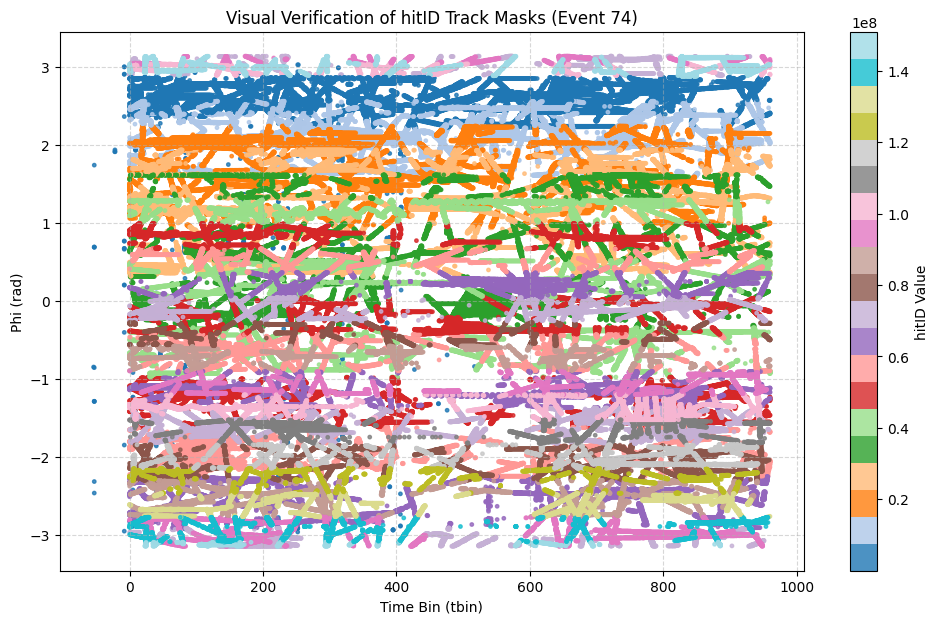

In [3]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd

# 1. Open the latest cycle of ntp_hit
file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
tree = uproot.open(file_path)["ntp_hit"]

# 2. Extract arrays into a Pandas DataFrame
# Note: Double-check capitalization (e.g., hitID vs hitid) via tree.keys() if needed
df = tree.arrays(["event", "phi", "tbin", "layer", "hitID", "adc"], library="pd")

# 3. Isolate a single event with valid charge deposits
event_id = 74
event_df = df[(df["event"] == event_id) & (df["adc"] > 0)]

# 4. Plot Phi vs Time Bin, color-coded by hitID
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    event_df["tbin"], 
    event_df["phi"], 
    c=event_df["hitID"], 
    cmap="tab20",  # Qualitative map helps separate discrete ID clusters
    s=6, 
    alpha=0.8
)

plt.colorbar(scatter, label="hitID Value")
plt.xlabel("Time Bin (tbin)")
plt.ylabel("Phi (rad)")
plt.title(f"Visual Verification of hitID Track Masks (Event {event_id})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("Event74VisualCheck.png")
plt.show()

In [2]:
import uproot
import pandas as pd
import numpy as np

# 1. Open the file and load the tree
file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
tree = uproot.open(file_path)["ntp_hit"]

# 2. Extract arrays into Pandas (Load only what we need to save memory)
print("Reading tracking trees from ROOT file...")
df = tree.arrays(["event", "layer", "hitID", "adc"], library="pd")

# Filter out dead channels / zero-suppression hits immediately
df = df[df["adc"] > 0]

print(f"Total active hits extracted across all events: {len(df):,}")

# 3. Perform a thorough aggregate analysis per event
print("\nAuditing dataset structure per event...")
event_grouped = df.groupby("event")

event_metrics = event_grouped.agg(
    total_hits=("hitID", "count"),
    unique_tracks=("hitID", "nunique"),
    min_layer=("layer", "min"),
    max_layer=("layer", "max")
).reset_index()

# Calculate the average tracking cluster density per event
event_metrics["avg_hits_per_track"] = event_metrics["total_hits"] / event_metrics["unique_tracks"]

# 4. Display Global Dataset Health Summary
print("\n" + "="*50)
print("          GLOBAL DATASET HEALTH REPORT          ")
print("="*50)
print(f"Total unique collision events found : {len(event_metrics)}")
print(f"Average hits per event (multiplicity): {event_metrics['total_hits'].mean():.1f}")
print(f"Average unique tracks per event      : {event_metrics['unique_tracks'].mean():.1f}")
print(f"Average hit points per single track  : {event_metrics['avg_hits_per_track'].mean():.1f}")
print(f"Global detector layer range span     : Layer {int(df['layer'].min())} to Layer {int(df['layer'].max())}")
print("="*50)

# 5. Check for ML Ground-Truth Red Flags
print("\nRunning automated ML data integrity validation checks...")

# Check for orphan hits (Unassigned track IDs often labeled as -1 or 0 depending on setup)
noise_labels = [-1, 0]
for noise_val in noise_labels:
    noise_count = (df["hitID"] == noise_val).sum()
    if noise_count > 0:
        pct_noise = (noise_count / len(df)) * 180
        print(f"  [⚠️ WARNING] Found {noise_count:,} hits with hitID == {noise_val} ({pct_noise:.2f}% of data).")
        print(f"               These are background noise/artifacts. Mask them or treat them as a dedicated class.")

# Check for single-hit anomalies (Tracks that only have 1 hit total across the entire event)
track_counts = df.groupby(["event", "hitID"]).size().reset_index(name="track_size")
single_hit_tracks = track_counts[track_counts["track_size"] == 1]
if len(single_hit_tracks) > 0:
    print(f"  [⚠️ WARNING] Found {len(single_hit_tracks)} single-hit track instances.")
    print(f"               Real physics tracks span multiple layers. These are likely standalone hot-pads.")
else:
    print("  [✓ PASSED] No single-hit track anomalies found.")

# Save the full event table for your records/plots
event_metrics.to_csv("global_event_summary.csv", index=False)
print("\nThorough examination complete. Summary table saved to 'global_event_summary.csv'.")

Reading tracking trees from ROOT file...
Total active hits extracted across all events: 25,869,501

Auditing dataset structure per event...

          GLOBAL DATASET HEALTH REPORT          
Total unique collision events found : 100
Average hits per event (multiplicity): 258695.0
Average unique tracks per event      : 102114.6
Average hit points per single track  : 2.5
Global detector layer range span     : Layer 3 to Layer 56

Running automated ML data integrity validation checks...
  [⚠️ WARNING] Found 88 hits with hitID == 0 (0.00% of data).
               These are background noise/artifacts. Mask them or treat them as a dedicated class.
  [⚠️ WARNING] Found 4503441 single-hit track instances.
               Real physics tracks span multiple layers. These are likely standalone hot-pads.

Thorough examination complete. Summary table saved to 'global_event_summary.csv'.


Loading tracking tree into memory...

Analyzing Event 100: Total active hits = 291,171

             HIT ID CLASSIFICATION SUMMARY             
Total Unique hitIDs Found     : 113,056
SIGNAL hitIDs (Hits >= 4)   : 22,422
BACKGROUND hitIDs (Hits < 4): 90,634
------------------------------------------------------------

Sample SIGNAL Track hitIDs (Long, continuous paths):
     hitID  track_multiplicity  span_layers
68092080.0                  51          5.0
40829608.0                  48         25.0
68092096.0                  47         16.0
43647016.0                  42         26.0
68026528.0                  41         12.0
69533864.0                  40         39.0
43712552.0                  40         27.0
67960992.0                  40         16.0
98762816.0                  39         27.0
68092128.0                  39         11.0

Sample BACKGROUND hitIDs (Isolated noise / delta rays):
 hitID  track_multiplicity  span_layers
   0.0                   1          1.0
   1.0

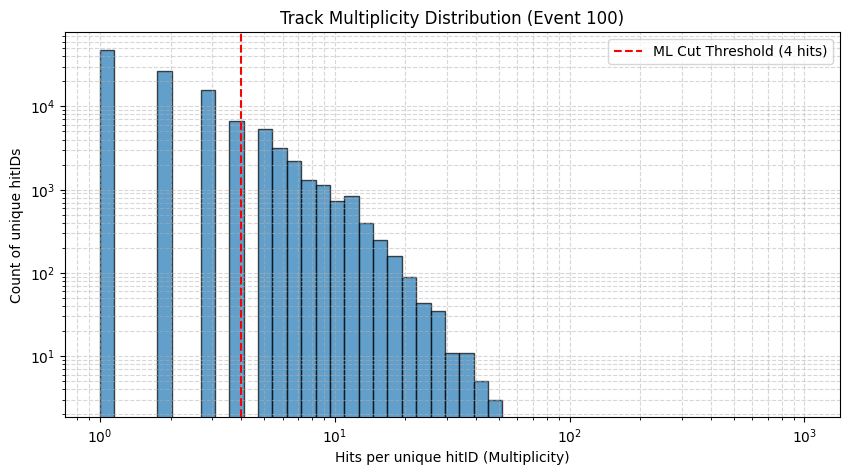

In [20]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Open the ROOT file and load the ntp_hit tree
file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
tree = uproot.open(file_path)["ntp_hit"]

# Load branches for an exemplary segment or the first few events to optimize memory
# We only need event, layer, and hitID for this check
print("Loading tracking tree into memory...")
df = tree.arrays(["event", "layer", "hitID", "adc"], library="pd")

# Filter out passive or zero-charge channels
df = df[df["adc"] > 0]

# 2. Isolate a single event to examine individual hitID behaviors clearly
# (Let's select Event 74 as our benchmark)
target_event = 100
event_df = df[df["event"] == target_event]

print(f"\nAnalyzing Event {target_event}: Total active hits = {len(event_df):,}")

# 3. Calculate the multiplicity (size) of each unique hitID
track_sizes = event_df.groupby("hitID").size().reset_index(name="track_multiplicity")

# Merge multiplicity back to see the layer span of each hitID
track_layer_spans = event_df.groupby("hitID")["layer"].agg(
    span_layers=lambda x: x.max() - x.min() + 1
).reset_index()

hit_profiles = pd.merge(track_sizes, track_layer_spans, on="hitID")

# 4. Define Threshold Criteria for Signal vs. Background Noise
# Standard physics tracks usually require at least 4 hits to form a seed track stub
min_signal_hits = 4 

signal_profiles = hit_profiles[hit_profiles["track_multiplicity"] >= min_signal_hits]
background_profiles = hit_profiles[hit_profiles["track_multiplicity"] < min_signal_hits]

# 5. Extract the explicit lists of hitID values
signal_hit_ids = signal_profiles["hitID"].tolist()
background_hit_ids = background_profiles["hitID"].tolist()

print("\n" + "="*60)
print("             HIT ID CLASSIFICATION SUMMARY             ")
print("="*60)
print(f"Total Unique hitIDs Found     : {len(hit_profiles):,}")
print(f"SIGNAL hitIDs (Hits >= {min_signal_hits})   : {len(signal_hit_ids):,}")
print(f"BACKGROUND hitIDs (Hits < {min_signal_hits}): {len(background_hit_ids):,}")
print("-"*60)

# Print a few examples of verified Signal Track IDs
print("\nSample SIGNAL Track hitIDs (Long, continuous paths):")
print(signal_profiles.sort_values(by="track_multiplicity", ascending=False).head(10).to_string(index=False))

# Print a few examples of verified Background Clutter IDs
print("\nSample BACKGROUND hitIDs (Isolated noise / delta rays):")
print(background_profiles.head(10).to_string(index=False))
print("="*60)

# 6. Optional: Create a Verification Plot to validate the threshold selection
plt.figure(figsize=(10, 5))
plt.hist(hit_profiles["track_multiplicity"], bins=np.logspace(0, 3, 50), edgecolor='k', alpha=0.7)
plt.gca().set_xscale("log")
plt.gca().set_yscale("log")
plt.axvline(x=min_signal_hits, color='r', linestyle='--', label=f'ML Cut Threshold ({min_signal_hits} hits)')
plt.xlabel("Hits per unique hitID (Multiplicity)")
plt.ylabel("Count of unique hitIDs")
plt.title(f"Track Multiplicity Distribution (Event {target_event})")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.savefig("hitID_multiplicity_distribution.png", bbox_inches='tight')
print("\nMultiplicity diagnosis plot saved as 'hitID_multiplicity_distribution.png'.")

In [21]:
import uproot
import pandas as pd
import numpy as np

# 1. Open the ROOT file and load the ntp_hit tree
file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
tree = uproot.open(file_path)["ntp_hit"]

print("Loading tracking tree for all 100 events...")
# Extracting only the required branches to maximize memory efficiency
df = tree.arrays(["event", "hitID", "adc"], library="pd")

# Filter out dead channels immediately
df = df[df["adc"] > 0]
print(f"Total active hits loaded: {len(df):,}")

# 2. Vectorized calculation of track multiplicities per event and per hitID
print("Calculating track multiplicities across the entire dataset...")
# Group by both event and hitID to find how many hits each track has in each event
track_counts = df.groupby(["event", "hitID"]).size().reset_index(name="multiplicity")

# 3. Define the ML signal cutoff threshold
min_signal_hits = 4

# Add binary classification flag: 1 for real track signal, 0 for micro-noise/background
track_counts["is_signal"] = (track_counts["multiplicity"] >= min_signal_hits).astype(int)

# 4. Aggregate the final summary metrics per event
print("Aggregating signal vs background distributions...")
event_grouped = df.groupby("event")
total_hits_per_event = event_grouped.size()

summary_grouped = track_counts.groupby("event")
event_summary = summary_grouped.agg(
    unique_hit_ids=("hitID", "count"),
    signal_tracks=("is_signal", "sum"),
).reset_index()

# Map total hits back to the summary table
event_summary["total_active_hits"] = event_summary["event"].map(total_hits_per_event)
# Background tracks = Total unique IDs - Signal tracks
event_summary["background_tracks"] = event_summary["unique_hit_ids"] - event_summary["signal_tracks"]

# Ensure integer types for cleaner printing
event_summary = event_summary.astype(int)

# 5. Print out the formatted report for all 100 events sequentially
print("\n" + "="*60)
print("       ALL EVENTS GROUND-TRUTH SEPARATION AUDIT        ")
print("="*60)

for _, row in event_summary.iterrows():
    ev = row["event"]
    print(f"Analyzing Event {ev}: Total active hits = {row['total_active_hits']:,}")
    print(f"============================================================")
    print(f"             HIT ID CLASSIFICATION SUMMARY             ")
    print(f"============================================================")
    print(f"Total Unique hitIDs Found     : {row['unique_hit_ids']:,}")
    print(f"SIGNAL hitIDs (Hits >= {min_signal_hits})   : {row['signal_tracks']:,}")
    print(f"BACKGROUND hitIDs (Hits < {min_signal_hits}): {row['background_tracks']:,}")
    print(f"------------------------------------------------------------\n")

# 6. Save the master report as a CSV for model benchmarking
output_csv = "all_events_hitID_summary.csv"
event_summary.to_csv(output_csv, index=False)
print(f"Global cross-event summary saved successfully to '{output_csv}'.")

Loading tracking tree for all 100 events...
Total active hits loaded: 25,869,501
Calculating track multiplicities across the entire dataset...
Aggregating signal vs background distributions...

       ALL EVENTS GROUND-TRUTH SEPARATION AUDIT        
Analyzing Event 1: Total active hits = 58,339
             HIT ID CLASSIFICATION SUMMARY             
Total Unique hitIDs Found     : 23,825
SIGNAL hitIDs (Hits >= 4)   : 4,512
BACKGROUND hitIDs (Hits < 4): 19,313
------------------------------------------------------------

Analyzing Event 2: Total active hits = 197,229
             HIT ID CLASSIFICATION SUMMARY             
Total Unique hitIDs Found     : 76,157
SIGNAL hitIDs (Hits >= 4)   : 15,480
BACKGROUND hitIDs (Hits < 4): 60,677
------------------------------------------------------------

Analyzing Event 3: Total active hits = 123,553
             HIT ID CLASSIFICATION SUMMARY             
Total Unique hitIDs Found     : 50,268
SIGNAL hitIDs (Hits >= 4)   : 9,453
BACKGROUND hitIDs 

In [22]:
import pandas as pd
import numpy as np

# 1. Load the generated summary data
csv_file = "all_events_hitID_summary.csv"
try:
    df = pd.read_csv(csv_file)
except FileNotFoundError:
    print(f"Error: Could not find '{csv_file}'. Make sure it is in your current directory.")
    exit()

# Ensure standard column names and sorting
df = df.sort_values(by="event").reset_index(drop=True)

# 2. Sequentially loop over all events and display the customized summary block
print("=" * 60)
print("       ALL 100 EVENTS GROUND-TRUTH SEPARATION AUDIT       ")
print("=" * 60)

for _, row in df.iterrows():
    # Parse metrics safely as integers
    ev = int(row["event"])
    total_hits = int(row["total_active_hits"])
    unique_ids = int(row["unique_hit_ids"])
    signal_tracks = int(row["signal_tracks"])
    bg_tracks = int(row["background_tracks"])
    
    # Calculate percentage-based metrics for better context
    bg_percentage = (bg_tracks / unique_ids) * 100 if unique_ids > 0 else 0
    
    print(f"Analyzing Event {ev}: Total active hits = {total_hits:,}")
    print(f"============================================================")
    print(f"             HIT ID CLASSIFICATION SUMMARY             ")
    print(f"============================================================")
    print(f"Total Unique hitIDs Found     : {unique_ids:,}")
    print(f"SIGNAL hitIDs (Hits >= 4)   : {signal_tracks:,}")
    print(f"BACKGROUND hitIDs (Hits < 4): {bg_tracks:,} ({bg_percentage:.2f}% of IDs)")
    print(f"------------------------------------------------------------\n")

# 3. Compute Global Cross-Event Multiplicity & Noise Extremes for ML Batching
print("=" * 60)
print("            MASTER ML TRAINING SPLIT INSIGHTS             ")
print("=" * 60)

# Find busiest and quietest collision environments
idx_max_hits = df["total_active_hits"].idxmax()
idx_min_hits = df["total_active_hits"].idxmin()

# Calculate signal-to-noise ratio per event (Signal tracks / Background tracks)
df["snr"] = df["signal_tracks"] / df["background_tracks"]
idx_max_snr = df["snr"].idxmax()
idx_min_snr = df["snr"].idxmin()

print(f"Total Events Audited            : {len(df)}")
print(f"Average Active Hits/Event       : {df['total_active_hits'].mean():,.1f}")
print(f"Global Signal Track Base        : {df['signal_tracks'].sum(),}")
print(f"Global Micro-Noise Tracker Base : {df['background_tracks'].sum(),}")
print(f"Dataset-Wide Tracking Purity    : {(df['signal_tracks'].sum() / df['unique_hit_ids'].sum()) * 100:.2f}%")
print("-" * 60)
print(f"🔥 Busiest Event (High Occupancy Testing) : Event {int(df.loc[idx_max_hits, 'event'])} with {int(df.loc[idx_max_hits, 'total_active_hits']):,} hits")
print(f"❄️  Quietest Event (Clean Baseline Testing): Event {int(df.loc[idx_min_hits, 'event'])} with {int(df.loc[idx_min_hits, 'total_active_hits']):,} hits")
print(f"📈 Cleanest Event (Highest SNR ratio)      : Event {int(df.loc[idx_max_snr, 'event'])} (SNR: {df.loc[idx_max_snr, 'snr']:.4f})")
print(f"📉 Messiest Event (Lowest SNR / High Noise) : Event {int(df.loc[idx_min_snr, 'event'])} (SNR: {df.loc[idx_min_snr, 'snr']:.4f})")
print("=" * 60)

       ALL 100 EVENTS GROUND-TRUTH SEPARATION AUDIT       
Analyzing Event 1: Total active hits = 58,339
             HIT ID CLASSIFICATION SUMMARY             
Total Unique hitIDs Found     : 23,825
SIGNAL hitIDs (Hits >= 4)   : 4,512
BACKGROUND hitIDs (Hits < 4): 19,313 (81.06% of IDs)
------------------------------------------------------------

Analyzing Event 2: Total active hits = 197,229
             HIT ID CLASSIFICATION SUMMARY             
Total Unique hitIDs Found     : 76,157
SIGNAL hitIDs (Hits >= 4)   : 15,480
BACKGROUND hitIDs (Hits < 4): 60,677 (79.67% of IDs)
------------------------------------------------------------

Analyzing Event 3: Total active hits = 123,553
             HIT ID CLASSIFICATION SUMMARY             
Total Unique hitIDs Found     : 50,268
SIGNAL hitIDs (Hits >= 4)   : 9,453
BACKGROUND hitIDs (Hits < 4): 40,815 (81.19% of IDs)
------------------------------------------------------------

Analyzing Event 4: Total active hits = 123,201
             HI

In [25]:
import uproot
import pandas as pd

# Define the path to your ROOT file
file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"

print("Loading ROOT file...")
with uproot.open(file_path) as root_file:
    
    # 1. Load the ntp_info tree (Global Event level)
    # We load 'event' and 'occ11' to see the macroscopic occupancy
    df_info = root_file["ntp_info"].arrays(["event", "occ11"], library="pd")
    
    # 2. Load the ntp_cluster tree (Local Cluster level)
    # We load a subset of columns to save memory
    df_cluster = root_file["ntp_cluster"].arrays(["event", "occ11"], library="pd")

print("\n--- TEST 1: Are 'occ' values constant for all clusters inside a single event? ---")
# Group clusters by their event ID, and count the number of UNIQUE occ11 values per event
unique_occ_per_event = df_cluster.groupby('event')['occ11'].nunique()

# If occ11 is a global feature, every event should have exactly 1 unique occ11 value across all its clusters
if (unique_occ_per_event == 1).all():
    print("✅ SUCCESS: Every single cluster within the same event has the exact same 'occ11' value. It does not vary hit-by-hit.")
else:
    print("❌ FAILED: Found varying 'occ11' values within the same event.")


print("\n--- TEST 2: Do the cluster-level 'occ' values match the global 'ntp_info' values? ---")
# Grab the first 3 event IDs to compare
sample_events = df_info['event'].head(100).values

for ev in sample_events:
    # Extract the macroscopic occupancy from ntp_info
    info_occ11 = df_info[df_info['event'] == ev]['occ11'].iloc[0]
    
    # Extract the occupancy from the clusters in ntp_cluster
    cluster_subset = df_cluster[df_cluster['event'] == ev]
    cluster_occ11 = cluster_subset['occ11'].iloc[0]
    num_clusters = len(cluster_subset)
    
    print(f"Event {ev}:")
    print(f"  -> Total clusters in this event: {num_clusters}")
    print(f"  -> occ11 value in ntp_info:      {info_occ11}")
    print(f"  -> occ11 value in ntp_cluster:   {cluster_occ11}")
    print(f"  -> Match? {'✅ Yes' if info_occ11 == cluster_occ11 else '❌ No'}\n")

Loading ROOT file...

--- TEST 1: Are 'occ' values constant for all clusters inside a single event? ---
✅ SUCCESS: Every single cluster within the same event has the exact same 'occ11' value. It does not vary hit-by-hit.

--- TEST 2: Do the cluster-level 'occ' values match the global 'ntp_info' values? ---
Event 1.0:
  -> Total clusters in this event: 9712
  -> occ11 value in ntp_info:      0.0008977795368991792
  -> occ11 value in ntp_cluster:   0.0008977795368991792
  -> Match? ✅ Yes

Event 2.0:
  -> Total clusters in this event: 25645
  -> occ11 value in ntp_info:      0.0033816073555499315
  -> occ11 value in ntp_cluster:   0.0033816073555499315
  -> Match? ✅ Yes

Event 3.0:
  -> Total clusters in this event: 17133
  -> occ11 value in ntp_info:      0.0023600261192768812
  -> occ11 value in ntp_cluster:   0.0023600261192768812
  -> Match? ✅ Yes

Event 4.0:
  -> Total clusters in this event: 17407
  -> occ11 value in ntp_info:      0.002560013672336936
  -> occ11 value in ntp_cluste

In [28]:
import uproot
import pandas as pd
import numpy as np

# Define the path to your ROOT file
file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"

print("Loading ROOT file and extracting trees...")
with uproot.open(file_path) as root_file:
    
    # 1. Load the RAW CLUSTERS (The "Island" algorithm output = Signal + Noise)
    # We load the basic spatial and identifier branches
    df_raw = root_file["ntp_cluster"].arrays(["event", "layer", "x", "y", "z"], library="pd")
    
    # 2. Load the VERIFIED TRACK CLUSTERS (The "Truth" map = Signal Only)
    # We load the spatial branches PLUS a physics branch ('spt' = transverse momentum) 
    # to prove these hits belong to a calculated particle trajectory
    df_truth = root_file["ntp_clus_trk"].arrays(["event", "layer", "x", "y", "z", "spt"], library="pd")

# Filter down to a single event (e.g., Event 74) to make the math easy to see
event_id = 74
df_raw_ev = df_raw[df_raw['event'] == event_id].copy()
df_truth_ev = df_truth[df_truth['event'] == event_id].copy()

print(f"\n--- DATASET SIZES FOR EVENT {event_id} ---")
print(f"Total Raw Clusters found by Island Alg : {len(df_raw_ev):,}")
print(f"Clusters assigned to valid Tracks      : {len(df_truth_ev):,}")

# --- ML Ground Truth Labeling ---
# To prove ntp_clus_trk is a matching subset, we perform a Left Join on the spatial coordinates.
# Because ROOT handles floats with high precision, we round slightly to ensure perfect pandas merging.
merge_keys = ['event', 'layer', 'x', 'y', 'z']
df_raw_ev[merge_keys] = df_raw_ev[merge_keys].round(4)
df_truth_ev[merge_keys] = df_truth_ev[merge_keys].round(4)

# Perform the merge. The 'indicator=True' flag tells us if the cluster exists in BOTH trees.
df_labeled = pd.merge(df_raw_ev, df_truth_ev, on=merge_keys, how='left', indicator=True)

# Create the Machine Learning Target Label
# If the hit exists in 'both', it is part of a real track (Signal = 1)
# If the hit only exists in 'left_only', it is background noise (Signal = 0)
df_labeled['is_signal'] = np.where(df_labeled['_merge'] == 'both', 1, 0)

# Drop the temporary merge indicator
df_labeled = df_labeled.drop(columns=['_merge'])

# --- VERIFICATION RESULTS ---
total_hits = len(df_labeled)
signal_hits = df_labeled['is_signal'].sum()
noise_hits = total_hits - signal_hits
purity = (signal_hits / total_hits) * 100

print("\n--- MACHINE LEARNING TARGET VERIFICATION ---")
print(f"Dataset Successfully Labeled!")
print(f"Signal Hits (is_signal = 1) : {signal_hits:,} ({purity:.2f}%) -> Contains 'spt' momentum features")
print(f"Noise Hits  (is_signal = 0) : {noise_hits:,} ({(100-purity):.2f}%) -> 'spt' is NaN")

print("\nSample of your newly labeled Training Data:")
print(df_labeled[['layer', 'x', 'y', 'z', 'spt', 'is_signal']].head(10000))

Loading ROOT file and extracting trees...

--- DATASET SIZES FOR EVENT 74 ---
Total Raw Clusters found by Island Alg : 46,755
Clusters assigned to valid Tracks      : 3,292

--- MACHINE LEARNING TARGET VERIFICATION ---
Dataset Successfully Labeled!
Signal Hits (is_signal = 1) : 3,292 (7.04%) -> Contains 'spt' momentum features
Noise Hits  (is_signal = 0) : 43,468 (92.96%) -> 'spt' is NaN

Sample of your newly labeled Training Data:
      layer          x       y           z  spt  is_signal
0       0.0   2.959600  0.7342   -9.080500  NaN          0
1       0.0   3.347800 -0.0286   -9.576800  NaN          0
2       0.0   2.959400  0.7347   -9.080700  NaN          0
3       0.0   3.347800 -0.0286   -9.576800  NaN          0
4       0.0   3.335600 -0.0046  -10.062200  NaN          0
...     ...        ...     ...         ...  ...        ...
9995   14.0  34.669800 -7.4517   43.752499  NaN          0
9996   14.0  34.948002 -6.0222 -195.199997  NaN          0
9997   14.0  34.469200  8.3132  -

In [48]:
import uproot

file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"

with uproot.open(file_path) as root_file:
    print("--- ntp_hit branches ---")
    print(root_file["ntp_hit"].keys())
    
    print("\n--- ntp_cluster branches ---")
    print(root_file["ntp_cluster"].keys())
    
    print("\n--- ntp_clus_trk branches ---")
    print(root_file["ntp_clus_trk"].keys())

--- ntp_hit branches ---
['event', 'seed', 'run', 'seg', 'job', 'hitID', 'e', 'adc', 'layer', 'phielem', 'zelem', 'cellID', 'ecell', 'phibin', 'zbin', 'tbin', 'phi', 'r', 'x', 'y', 'z', 'occ11', 'occ116', 'occ21', 'occ216', 'occ31', 'occ316', 'rawzdc', 'livezdc', 'scaledzdc', 'rawmbd', 'livembd', 'scaledmbd', 'rawmbdv10', 'livembdv10', 'scaledmbdv10', 'rawzdc1', 'livezdc1', 'scaledzdc1', 'rawmbd1', 'livembd1', 'scaledmbd1', 'rawmbdv101', 'livembdv101', 'scaledmbdv101', 'rzdc', 'rmbd', 'rmbdv10', 'bco1', 'bco', 'bcotr', 'bcotr1', 'ntrk', 'ntpcseed', 'nsiseed', 'nhitmvtx', 'nhitintt', 'nhittpot', 'nhittpcall', 'nhittpcin', 'nhittpcmid', 'nhittpcout', 'nclusall', 'nclustpc', 'nclustpcpos', 'nclustpcneg', 'nclusintt', 'nclusmaps', 'nclusmms']

--- ntp_cluster branches ---
['event', 'seed', 'run', 'seg', 'job', 'locx', 'locy', 'x', 'y', 'z', 'r', 'phi', 'eta', 'theta', 'phibin', 'tbin', 'fee', 'chan', 'sampa', 'ex', 'ey', 'ez', 'ephi', 'pez', 'pephi', 'e', 'adc', 'maxadc', 'thick', 'afac', 

In [58]:
import uproot
import pandas as pd
import numpy as np

# 1. Open ROOT file and connect to the two trees
file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
tree_hit = uproot.open(file_path)["ntp_hit"]
tree_trk = uproot.open(file_path)["ntp_clus_trk"]

print("Loading trees into memory...")
# We use the discrete detector pad coordinates as our "Bridge" keys
bridge_keys = ["event", "layer", "tbin", "phielem", "zelem"]

# Load Raw Hits (Contains the true particle hitID)
df_hit = tree_hit.arrays(bridge_keys + ["hitID", "adc"], library="pd")
df_hit = df_hit[df_hit["adc"] > 0]

# Load Verified Track Clusters (The official "Signal" list)
df_trk = tree_trk.arrays(bridge_keys, library="pd")
df_trk["is_verified"] = 1
df_trk = df_trk.drop_duplicates(subset=bridge_keys)

# 2. THE BRIDGE: Map the verified track flag back onto the raw truth hits
print("Performing Spatial Inner Join (The Cluster Bridge)...")
df_merged = pd.merge(df_hit, df_trk, on=bridge_keys, how="left")
df_merged["is_verified"] = df_merged["is_verified"].fillna(0).astype(int)

# 3. Analyze Track Survival Rates by hitID
print("Calculating official tracking software rejection rates...")
# Group by particle (hitID) per event
track_stats = df_merged.groupby(["event", "hitID"]).agg(
    multiplicity=("hitID", "count"),
    verified_hits=("is_verified", "sum")
).reset_index()

# We consider a truth particle "Successfully Reconstructed" if the tracking 
# algorithm salvaged at least one of its clusters into the final ntp_clus_trk tree.
track_stats["track_survived"] = (track_stats["verified_hits"] > 0).astype(int)

# 4. Generate the Final Proof Report binned by Multiplicity
survival_report = track_stats.groupby("multiplicity").agg(
    total_truth_particles=("hitID", "count"),
    surviving_particles=("track_survived", "sum")
).reset_index()

# Calculate the rejection rate
survival_report["rejection_rate_%"] = 100 * (1 - survival_report["surviving_particles"] / survival_report["total_truth_particles"])

# Format for nice console printing
print("\n" + "="*70)
print("   ntp_clus_trk REJECTION RATE BY TRUTH MULTIPLICITY")
print("="*70)
print(f"{'Multiplicity (Hits)':<20} | {'Total Generated':<15} | {'Rejection Rate':<15}")
print("-" * 70)

# Print stats for multiplicity 1 through 6, then aggregate > 6
for i in range(1, 130):
    row = survival_report[survival_report["multiplicity"] == i]
    if not row.empty:
        total = int(row["total_truth_particles"].iloc[0])
        rej_rate = float(row["rejection_rate_%"].iloc[0])
        print(f" {i} hit(s) {' ':<11} | {total:<15,} | {rej_rate:>6.2f}% rejected")

# Aggregate long, valid physics tracks (hits >= 7)
long_tracks = survival_report[survival_report["multiplicity"] >= 130]
total_long = long_tracks["total_truth_particles"].sum()
survived_long = long_tracks["surviving_particles"].sum()
rej_rate_long = 100 * (1 - survived_long / total_long) if total_long > 0 else 0

print("-" * 70)
print(f" >= 7 hits (Signal)  | {total_long:<15,} | {rej_rate_long:>6.2f}% rejected")
print("=" * 70)

Loading trees into memory...
Performing Spatial Inner Join (The Cluster Bridge)...
Calculating official tracking software rejection rates...

   ntp_clus_trk REJECTION RATE BY TRUTH MULTIPLICITY
Multiplicity (Hits)  | Total Generated | Rejection Rate 
----------------------------------------------------------------------
 1 hit(s)             | 4,503,441       | 100.00% rejected
 2 hit(s)             | 2,382,099       | 100.00% rejected
 3 hit(s)             | 1,364,808       | 100.00% rejected
 4 hit(s)             | 596,030         | 100.00% rejected
 5 hit(s)             | 461,602         | 100.00% rejected
 6 hit(s)             | 278,019         | 100.00% rejected
 7 hit(s)             | 188,014         | 100.00% rejected
 8 hit(s)             | 114,676         | 100.00% rejected
 9 hit(s)             | 98,971          | 100.00% rejected
 10 hit(s)             | 61,772          | 100.00% rejected
 11 hit(s)             | 39,660          | 100.00% rejected
 12 hit(s)             | 2

In [59]:
import uproot
file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
with uproot.open(file_path) as root_file:
    print("--- ntp_hit keys ---")
    print(root_file["ntp_hit"].keys())
    print("\n--- ntp_cluster keys ---")
    print(root_file["ntp_cluster"].keys())
    print("\n--- ntp_clus_trk keys ---")
    print(root_file["ntp_clus_trk"].keys())

--- ntp_hit keys ---
['event', 'seed', 'run', 'seg', 'job', 'hitID', 'e', 'adc', 'layer', 'phielem', 'zelem', 'cellID', 'ecell', 'phibin', 'zbin', 'tbin', 'phi', 'r', 'x', 'y', 'z', 'occ11', 'occ116', 'occ21', 'occ216', 'occ31', 'occ316', 'rawzdc', 'livezdc', 'scaledzdc', 'rawmbd', 'livembd', 'scaledmbd', 'rawmbdv10', 'livembdv10', 'scaledmbdv10', 'rawzdc1', 'livezdc1', 'scaledzdc1', 'rawmbd1', 'livembd1', 'scaledmbd1', 'rawmbdv101', 'livembdv101', 'scaledmbdv101', 'rzdc', 'rmbd', 'rmbdv10', 'bco1', 'bco', 'bcotr', 'bcotr1', 'ntrk', 'ntpcseed', 'nsiseed', 'nhitmvtx', 'nhitintt', 'nhittpot', 'nhittpcall', 'nhittpcin', 'nhittpcmid', 'nhittpcout', 'nclusall', 'nclustpc', 'nclustpcpos', 'nclustpcneg', 'nclusintt', 'nclusmaps', 'nclusmms']

--- ntp_cluster keys ---
['event', 'seed', 'run', 'seg', 'job', 'locx', 'locy', 'x', 'y', 'z', 'r', 'phi', 'eta', 'theta', 'phibin', 'tbin', 'fee', 'chan', 'sampa', 'ex', 'ey', 'ez', 'ephi', 'pez', 'pephi', 'e', 'adc', 'maxadc', 'thick', 'afac', 'bfac', 

In [61]:
import uproot
import pandas as pd

# 1. Open ROOT file and connect to the two trees
file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
tree_hit = uproot.open(file_path)["ntp_hit"]
tree_trk = uproot.open(file_path)["ntp_clus_trk"]

print("Loading trees into memory...")
bridge_keys = ["event", "layer", "tbin", "phielem", "zelem"]

# Load Raw Hits
df_hit = tree_hit.arrays(bridge_keys + ["hitID", "adc"], library="pd")
df_hit = df_hit[df_hit["adc"] > 0]

# Load Verified Track Clusters
df_trk = tree_trk.arrays(bridge_keys, library="pd")
df_trk["is_verified"] = 1
df_trk = df_trk.drop_duplicates(subset=bridge_keys)

print("Healing Floating-Point Mismatches and Cleaning Data...")

# --- THE FIX: Drop corrupted/null rows from our bridge keys ---
df_hit = df_hit.dropna(subset=bridge_keys)
df_trk = df_trk.dropna(subset=bridge_keys)

# 1. Cast discrete spatial grid locations to exact integers
exact_keys = ["event", "layer", "phielem", "zelem"]
df_hit[exact_keys] = df_hit[exact_keys].round().astype(int)
df_trk[exact_keys] = df_trk[exact_keys].round().astype(int)

# 2. Sort by the continuous variable (tbin) to prepare for the fuzzy join
df_hit = df_hit.sort_values("tbin")
df_trk = df_trk.sort_values("tbin")

print("Performing Fuzzy Spatial Join (The Cluster Bridge)...")
# 3. If a hit is on the same pad as a verified track, and within 3 time bins
#    of the cluster's center-of-mass, we flag it as successfully reconstructed!
df_merged = pd.merge_asof(
    df_hit,
    df_trk,
    on="tbin",
    by=exact_keys,
    tolerance=3.0,
    direction="nearest"
)

df_merged["is_verified"] = df_merged["is_verified"].fillna(0).astype(int)

print("Calculating official tracking software rejection rates...")
# Group by particle (hitID) per event
track_stats = df_merged.groupby(["event", "hitID"]).agg(
    multiplicity=("hitID", "count"),
    verified_hits=("is_verified", "sum")
).reset_index()

# If the algorithm salvaged at least one cluster from this particle, it "survived"
track_stats["track_survived"] = (track_stats["verified_hits"] > 0).astype(int)

# Generate the Final Proof Report binned by Multiplicity
survival_report = track_stats.groupby("multiplicity").agg(
    total_truth_particles=("hitID", "count"),
    surviving_particles=("track_survived", "sum")
).reset_index()

survival_report["rejection_rate_%"] = 100 * (1 - survival_report["surviving_particles"] / survival_report["total_truth_particles"])

# Format for nice console printing
print("\n" + "="*70)
print("   ntp_clus_trk REJECTION RATE BY TRUTH MULTIPLICITY")
print("="*70)
print(f"{'Multiplicity (Hits)':<20} | {'Total Generated':<15} | {'Rejection Rate':<15}")
print("-" * 70)

for i in range(1, 15):
    row = survival_report[survival_report["multiplicity"] == i]
    if not row.empty:
        total = int(row["total_truth_particles"].iloc[0])
        rej_rate = float(row["rejection_rate_%"].iloc[0])
        print(f" {i} hit(s) {' ':<11} | {total:<15,} | {rej_rate:>6.2f}% rejected")

# Aggregate long, valid physics tracks (hits >= 15)
long_tracks = survival_report[survival_report["multiplicity"] >= 15]
if not long_tracks.empty:
    total_long = long_tracks["total_truth_particles"].sum()
    survived_long = long_tracks["surviving_particles"].sum()
    rej_rate_long = 100 * (1 - survived_long / total_long) if total_long > 0 else 0
    print("-" * 70)
    print(f" >= 15 hits (Signal) | {total_long:<15,} | {rej_rate_long:>6.2f}% rejected")
print("=" * 70)

Loading trees into memory...
Healing Floating-Point Mismatches and Cleaning Data...
Performing Fuzzy Spatial Join (The Cluster Bridge)...
Calculating official tracking software rejection rates...

   ntp_clus_trk REJECTION RATE BY TRUTH MULTIPLICITY
Multiplicity (Hits)  | Total Generated | Rejection Rate 
----------------------------------------------------------------------
 1 hit(s)             | 4,475,003       |  92.93% rejected
 2 hit(s)             | 2,357,867       |  90.06% rejected
 3 hit(s)             | 1,352,279       |  90.28% rejected
 4 hit(s)             | 591,214         |  87.76% rejected
 5 hit(s)             | 459,963         |  88.89% rejected
 6 hit(s)             | 277,577         |  87.28% rejected
 7 hit(s)             | 187,862         |  87.32% rejected
 8 hit(s)             | 114,612         |  85.66% rejected
 9 hit(s)             | 98,955          |  87.64% rejected
 10 hit(s)             | 61,766          |  86.04% rejected
 11 hit(s)             | 39,653

In [63]:
import uproot
import pandas as pd
import numpy as np
from scipy.spatial import KDTree

# 1. Open ROOT file and connect to the two trees
file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
tree_hit = uproot.open(file_path)["ntp_hit"]
tree_trk = uproot.open(file_path)["ntp_clus_trk"]

print("Loading spatial data into memory...")
# Load Raw Hits (The individual sensor pads)
df_hit = tree_hit.arrays(["event", "hitID", "layer", "x", "y", "z", "adc"], library="pd")
df_hit = df_hit[df_hit["adc"] > 0].reset_index(drop=True)
df_hit["is_verified"] = 0  # Default everything to Noise

# Load Verified Track Clusters (The center-of-mass targets)
df_trk = tree_trk.arrays(["event", "layer", "x", "y", "z"], library="pd")

print("Bridging hits to verified clusters using 3D KD-Trees...")
# We iterate by Event and Layer to ensure physical accuracy and high speed
verified_indices = []

for (ev, layer), hit_group in df_hit.groupby(['event', 'layer']):
    # Get the verified cluster centers for this exact event and layer
    trk_group = df_trk[(df_trk['event'] == ev) & (df_trk['layer'] == layer)]
    
    if trk_group.empty:
        continue
        
    # Build a fast 3D spatial search tree out of the Verified Clusters
    tree = KDTree(trk_group[['x', 'y', 'z']].values)
    
    # Query all raw hits in this layer against the cluster centers.
    # If a raw pad is within 1.5 cm of a verified cluster center, it is Signal.
    distances, _ = tree.query(hit_group[['x', 'y', 'z']].values, distance_upper_bound=1.5)
    
    # KDTree returns np.inf for hits outside the upper bound
    valid_mask = distances < np.inf
    
    # Save the dataframe indices of the hits that successfully mapped to a cluster
    verified_indices.extend(hit_group.index[valid_mask].tolist())

# Apply the True Signal Labels
df_hit.loc[verified_indices, 'is_verified'] = 1

print("Calculating official tracking software rejection rates...")
# Group by the Monte Carlo Particle ID (hitID) per event
track_stats = df_hit.groupby(["event", "hitID"]).agg(
    multiplicity=("hitID", "count"),
    verified_hits=("is_verified", "sum")
).reset_index()

# We consider a truth particle "Successfully Reconstructed" if the tracking 
# algorithm salvaged at least one blob (cluster) from its trajectory.
track_stats["track_survived"] = (track_stats["verified_hits"] > 0).astype(int)

# Generate the Final Proof Report binned by Multiplicity
survival_report = track_stats.groupby("multiplicity").agg(
    total_truth_particles=("hitID", "count"),
    surviving_particles=("track_survived", "sum")
).reset_index()

survival_report["rejection_rate_%"] = 100 * (1 - survival_report["surviving_particles"] / survival_report["total_truth_particles"])

# Format for nice console printing
print("\n" + "="*70)
print("   ntp_clus_trk REJECTION RATE BY TRUTH MULTIPLICITY")
print("="*70)
print(f"{'Multiplicity (Hits)':<20} | {'Total Generated':<15} | {'Rejection Rate':<15}")
print("-" * 70)

for i in range(1, 15):
    row = survival_report[survival_report["multiplicity"] == i]
    if not row.empty:
        total = int(row["total_truth_particles"].iloc[0])
        rej_rate = float(row["rejection_rate_%"].iloc[0])
        print(f" {i} hit(s) {' ':<11} | {total:<15,} | {rej_rate:>6.2f}% rejected")

# Aggregate long, valid physics tracks (hits >= 15)
long_tracks = survival_report[survival_report["multiplicity"] >= 15]
if not long_tracks.empty:
    total_long = long_tracks["total_truth_particles"].sum()
    survived_long = long_tracks["surviving_particles"].sum()
    rej_rate_long = 100 * (1 - survived_long / total_long) if total_long > 0 else 0
    print("-" * 70)
    print(f" >= 15 hits (Signal) | {total_long:<15,} | {rej_rate_long:>6.2f}% rejected")
print("=" * 70)

# Optional: Save your ML-ready Ground Truth dataset!
df_hit.to_csv("ML_Ground_Truth_Hits.csv", index=False)

Loading spatial data into memory...
Bridging hits to verified clusters using 3D KD-Trees...
Calculating official tracking software rejection rates...

   ntp_clus_trk REJECTION RATE BY TRUTH MULTIPLICITY
Multiplicity (Hits)  | Total Generated | Rejection Rate 
----------------------------------------------------------------------
 1 hit(s)             | 4,503,441       |  99.68% rejected
 2 hit(s)             | 2,382,099       |  99.58% rejected
 3 hit(s)             | 1,364,808       |  99.51% rejected
 4 hit(s)             | 596,030         |  99.43% rejected
 5 hit(s)             | 461,602         |  99.34% rejected
 6 hit(s)             | 278,019         |  99.23% rejected
 7 hit(s)             | 188,014         |  99.22% rejected
 8 hit(s)             | 114,676         |  99.05% rejected
 9 hit(s)             | 98,971          |  99.04% rejected
 10 hit(s)             | 61,772          |  98.97% rejected
 11 hit(s)             | 39,660          |  98.84% rejected
 12 hit(s)       

In [68]:
import uproot
import pandas as pd
import numpy as np

# 1. Define the file and the specific "matching" tree
file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
tree_name = "ntp_clus_trk"  # The bridge tree

# 2. Open the file (uproot automatically selects the correct current cycles)
with uproot.open(file_path) as file:
    tree = file[tree_name]
    
    # 3. Define the exact columns to extract
    # trackID replaces hitID as the Monte Carlo Truth identifier
    branches_to_extract = [
        "event",      # Event ID to group point clouds
        "trackID",    # Truth Particle ID (Track barcode) 
        "sR0",        # TARGET: True Simulated Radial Position
        "r",          # FEATURE: Reconstructed Cluster Radius
        "phi",        # FEATURE: Reconstructed Cluster Phi
        "z"           # FEATURE: Reconstructed Cluster Z
    ]
    
    # 4. Load the data directly into a Pandas DataFrame
    print(f"Extracting {tree_name}...")
    df = tree.arrays(branches_to_extract, library="pd")

# 5. Calculate the Alignment Error (How far off the legacy Island algorithm was)
# This creates a new column showing the exact residual error
df['radial_error'] = df['r'] - df['sR0']

# Show the first few rows to validate the mapping
print(df.head())

# Optional: Save to CSV for your PyTorch DataLoader
df.to_csv("training_labels_sR0_mapped.csv", index=False)
print("Data successfully saved to training_labels_sR0_mapped.csv")

Extracting ntp_clus_trk...
   event  trackID        sR0          r       phi          z  radial_error
0    1.0      NaN  14.309492  31.500067  2.673034 -68.816292     17.190575
1    1.0      NaN  14.309492  32.065319  2.667838 -69.098061     17.755827
2    1.0      NaN  14.309492  32.635384  2.665857 -69.150826     18.325891
3    1.0      NaN  14.309492  33.199680  2.659276 -69.318817     18.890188
4    1.0      NaN  14.309492  33.767075  2.656619 -69.505638     19.457582
Data successfully saved to training_labels_sR0_mapped.csv


In [67]:
import uproot

file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
tree_name = "ntp_clus_trk"

with uproot.open(file_path) as file:
    tree = file[tree_name]
    
    # This will print every single column name available in the ntp_clus_trk tree
    print("Available columns:", tree.keys())

Available columns: ['event', 'seed', 'run', 'seg', 'job', 'locx', 'locy', 'x', 'y', 'z', 'r', 'phi', 'eta', 'theta', 'phibin', 'tbin', 'fee', 'chan', 'sampa', 'ex', 'ey', 'ez', 'ephi', 'pez', 'pephi', 'e', 'adc', 'maxadc', 'thick', 'afac', 'bfac', 'dcal', 'layer', 'phielem', 'zelem', 'size', 'phisize', 'zsize', 'pedge', 'redge', 'ovlp', 'trackID', 'niter', 'alpha', 'beta', 'resphio', 'resphi', 'resz', 'seedID', 'siter', 'spt', 'sptot', 'seta', 'sphi', 'syxint', 'srzint', 'sxyslope', 'srzslope', 'sX0', 'sY0', 'sdZ0', 'sR0', 'scharge', 'sdedx', 'spidedx', 'skdedx', 'sprdedx', 'sn1pix', 'snsil', 'sntpc', 'snhits', 'occ11', 'occ116', 'occ21', 'occ216', 'occ31', 'occ316', 'rawzdc', 'livezdc', 'scaledzdc', 'rawmbd', 'livembd', 'scaledmbd', 'rawmbdv10', 'livembdv10', 'scaledmbdv10', 'rawzdc1', 'livezdc1', 'scaledzdc1', 'rawmbd1', 'livembd1', 'scaledmbd1', 'rawmbdv101', 'livembdv101', 'scaledmbdv101', 'rzdc', 'rmbd', 'rmbdv10', 'bco1', 'bco', 'bcotr', 'bcotr1', 'ntrk', 'ntpcseed', 'nsiseed', '

In [71]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

# 1. Load the data extracted from ROOT
df = pd.read_csv("training_labels_sR0_mapped.csv")

# FIX: Only drop NaNs in the columns we actually need for geometry!
df = df.dropna(subset=['r', 'phi', 'z', 'sR0'])

# 2. Build the Two Geometries
x_reconstructed = df['r'] * np.cos(df['phi'])
y_reconstructed = df['r'] * np.sin(df['phi'])

# --- Dataset A: Cartesian ---
X_cartesian = pd.DataFrame({
    'x': x_reconstructed,
    'y': y_reconstructed,
    'z': df['z']
})

# --- Dataset B: Cylindrical (with cyclic encoding) ---
X_cylindrical = pd.DataFrame({
    'r': df['r'], 
    'sin_phi': np.sin(df['phi']), 
    'cos_phi': np.cos(df['phi']), 
    'z': df['z']
})

# The Target is always the true Simulated Radial Position
y_target = df['sR0']

# 3. Normalize the data (Crucial for Neural Networks)
scaler_cart = StandardScaler()
scaler_cyl = StandardScaler()

X_cart_scaled = scaler_cart.fit_transform(X_cartesian)
X_cyl_scaled = scaler_cyl.fit_transform(X_cylindrical)

# 4. Create identical Train/Test splits to ensure a fair comparison
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cart_scaled, y_target, test_size=0.2, random_state=42
)
Xcy_train, Xcy_test, ycy_train, ycy_test = train_test_split(
    X_cyl_scaled, y_target, test_size=0.2, random_state=42
)

# 5. Train Baseline Neural Networks (Multi-Layer Perceptrons)
print(f"Dataset loaded with {len(df)} hits.")
print("Training Cartesian Model...")
mlp_cart = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp_cart.fit(Xc_train, yc_train)

print("Training Cylindrical Model...")
mlp_cyl = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp_cyl.fit(Xcy_train, ycy_train)

# 6. Evaluate and Compare
cart_error = mean_absolute_error(yc_test, mlp_cart.predict(Xc_test))
cyl_error = mean_absolute_error(ycy_test, mlp_cyl.predict(Xcy_test))

print("\n--- RESULTS: Mean Absolute Error (cm) ---")
print(f"Cartesian Coordinate Error:   {cart_error:.4f} cm")
print(f"Cylindrical Coordinate Error: {cyl_error:.4f} cm")

# Calculate the improvement
if cyl_error < cart_error:
    improvement = ((cart_error - cyl_error) / cart_error) * 100
    print(f"\nConclusion: Cylindrical coordinates improved accuracy by {improvement:.2f}%")
else:
    print("\nConclusion: Cartesian coordinates performed better or equally well in this baseline test.")

Dataset loaded with 221494 hits.
Training Cartesian Model...
Training Cylindrical Model...

--- RESULTS: Mean Absolute Error (cm) ---
Cartesian Coordinate Error:   7.5050 cm
Cylindrical Coordinate Error: 7.4545 cm

Conclusion: Cylindrical coordinates improved accuracy by 0.67%


Loading sample from clusters_seeds_island_79507-0.root_ntuplizer.root...

--- hitID REGIME AUDIT (Sample: 5M hits) ---
                                 unique_id_count  multiplicity    avg_adc  avg_layer_span
regime                                                                                   
Regime 1: < 75M (Signal?)                 481409      8.326284  87.166145       24.934435
Regime 2: 75M-100M (Secondary?)            44897     13.351493  99.478149       17.795399
Regime 3: > 100M (Noise?)                  61017      6.427881  94.483498        6.059114

--- ML PREPROCESSING INSIGHTS ---
[✓] Regime 1: < 75M (Signal?): Likely REAL TRACKS. Keep as primary training signal.
[✓] Regime 2: 75M-100M (Secondary?): Likely REAL TRACKS. Keep as primary training signal.
[✓] Regime 3: > 100M (Noise?): Likely REAL TRACKS. Keep as primary training signal.
